In [13]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel('dataset.xlsx')
df.columns

Index(['Age', 'Blood_Glucose_Level(BGL)', 'Diastolic_Blood_Pressure',
       'Systolic_Blood_Pressure', 'Heart_Rate', 'Body_Temperature', 'SPO2',
       'Sweating', 'Shivering', 'Diabetic/NonDiabetic'],
      dtype='str')

In [14]:
# Convert 'Blood_Glucose_Level(BGL)' and other numeric columns to numeric
numeric_columns = [
    'Blood_Glucose_Level(BGL)', 'Diastolic_Blood_Pressure', 
    'Systolic_Blood_Pressure', 'Heart_Rate', 'Body_Temperature', 'SPO2'
]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

df['Diabetic/NonDiabetic'] = df['Diabetic/NonDiabetic'].map({'N': 0, 'D': 1})


In [15]:
unique_rows = df.drop_duplicates()
num_unique_rows = len(unique_rows)

#print("Unique rows:\n", unique_rows)
print("Number of unique rows:", num_unique_rows)

Number of unique rows: 16715


In [16]:
# Count the number of diabetic and non-diabetic patients
diabetic_counts = df['Diabetic/NonDiabetic'].value_counts()

# Display the counts
print(diabetic_counts)

Diabetic/NonDiabetic
1    16641
0      328
Name: count, dtype: int64


In [17]:
# Select relevant features
selected_features = [
    'Diastolic_Blood_Pressure', 'Systolic_Blood_Pressure', 
    'Heart_Rate', 'Body_Temperature', 'SPO2'
]

# Apply a rolling window to create new features (e.g., 500-time-step rolling window)
window_size = 1500
df1500 = df.copy()  # Create a new DataFrame to store rolling window features

# Apply a rolling window in reverse (from behind)
for feature in selected_features:
    # Reverse the feature column, apply rolling window, and then reverse back
    df1500[f'{feature}_rolling_mean'] = df[feature].iloc[::-1].rolling(window=window_size).mean().iloc[::-1]
    df1500[f'{feature}_rolling_std'] = df[feature].iloc[::-1].rolling(window=window_size).std().iloc[::-1]

# Drop rows with NaN values after the rolling window
df1500 = df1500.dropna()

# Display the updated DataFrame
df1500.columns


Index(['Age', 'Blood_Glucose_Level(BGL)', 'Diastolic_Blood_Pressure',
       'Systolic_Blood_Pressure', 'Heart_Rate', 'Body_Temperature', 'SPO2',
       'Sweating', 'Shivering', 'Diabetic/NonDiabetic',
       'Diastolic_Blood_Pressure_rolling_mean',
       'Diastolic_Blood_Pressure_rolling_std',
       'Systolic_Blood_Pressure_rolling_mean',
       'Systolic_Blood_Pressure_rolling_std', 'Heart_Rate_rolling_mean',
       'Heart_Rate_rolling_std', 'Body_Temperature_rolling_mean',
       'Body_Temperature_rolling_std', 'SPO2_rolling_mean',
       'SPO2_rolling_std'],
      dtype='str')

In [18]:
# Count the number of diabetic and non-diabetic patients
diabetic_counts = df1500['Diabetic/NonDiabetic'].value_counts()

# Display the counts
print(diabetic_counts)

Diabetic/NonDiabetic
1    15142
0      328
Name: count, dtype: int64


In [19]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Encode categorical features
label_encoder = LabelEncoder()
df1500['Diabetic/NonDiabetic'] = label_encoder.fit_transform(df1500['Diabetic/NonDiabetic'])

# Define features and target variable
features = ['Blood_Glucose_Level(BGL)','Diastolic_Blood_Pressure_rolling_mean',
            'Diastolic_Blood_Pressure_rolling_std',
            'Systolic_Blood_Pressure_rolling_mean',
            'Systolic_Blood_Pressure_rolling_std', 
            'Heart_Rate_rolling_mean',
            'Heart_Rate_rolling_std', 
            'Body_Temperature_rolling_mean',
            'Body_Temperature_rolling_std', 
            'SPO2_rolling_mean',
            'SPO2_rolling_std']
target = 'Diabetic/NonDiabetic'  # Use the binary target variable for SMOTE

X = df1500[features]
y = df1500[target]

# Step 2: Apply SMOTE to the entire dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Step 3: Create a new DataFrame with the resampled data
df1500smote = pd.DataFrame(X_resampled, columns=features)
df1500smote[target] = y_resampled

# Display the counts of diabetic and non-diabetic patients in the new DataFrame
print(df1500smote[target].value_counts())

# Optional: Save the new DataFrame to a file if needed
# df1500smote.to_excel('df1500smote.xlsx', index=False)


Diabetic/NonDiabetic
0    15142
1    15142
Name: count, dtype: int64


DATA ANALYSIS

In [20]:
df = pd.read_excel("dataset.xlsx")
df.columns = df.columns.str.strip().str.replace(" ", "_")

target_col = "Blood_Glucose_Level(BGL)"
DIABETIC_THRESHOLD = 126.0

def classify_diabetes(bgl_series):
    return bgl_series.apply(
        lambda x: "Diabetic" if x >= DIABETIC_THRESHOLD else "Non-Diabetic"
    )

def summarize_distribution(df, label, age_col="Age", target_col="BGL_Status"):
    print(f"\n================ {label} ================")
    print(f"Total Count: {len(df)}")

    if age_col in df.columns and target_col in df.columns:
        summary = (
            pd.crosstab(df[age_col], df[target_col], margins=True)
            .rename_axis(index="Age", columns="Status")
        )
        print(summary)
    elif target_col in df.columns:
        print(df[target_col].value_counts())
    else:
        print("Age / Target status not available for breakdown.")

# Clean missing targets
df = df.dropna(subset=[target_col]).drop_duplicates()
df["BGL_Status"] = classify_diabetes(df[target_col])

summarize_distribution(df, "1. INITIAL RAW DATASET")


================ 1. INITIAL RAW DATASET ================
Total Count: 16715
Status  Diabetic  Non-Diabetic    All
Age                                  
9            682          5536   6218
14           191          2091   2282
15            35           242    277
19           115          1105   1220
30             0            98     98
36             0            58     58
44             0            29     29
46           174          1747   1921
51             0            28     28
55           124          1745   1869
66             0            20     20
76           244          2221   2465
77            14           216    230
All         1579         15136  16715


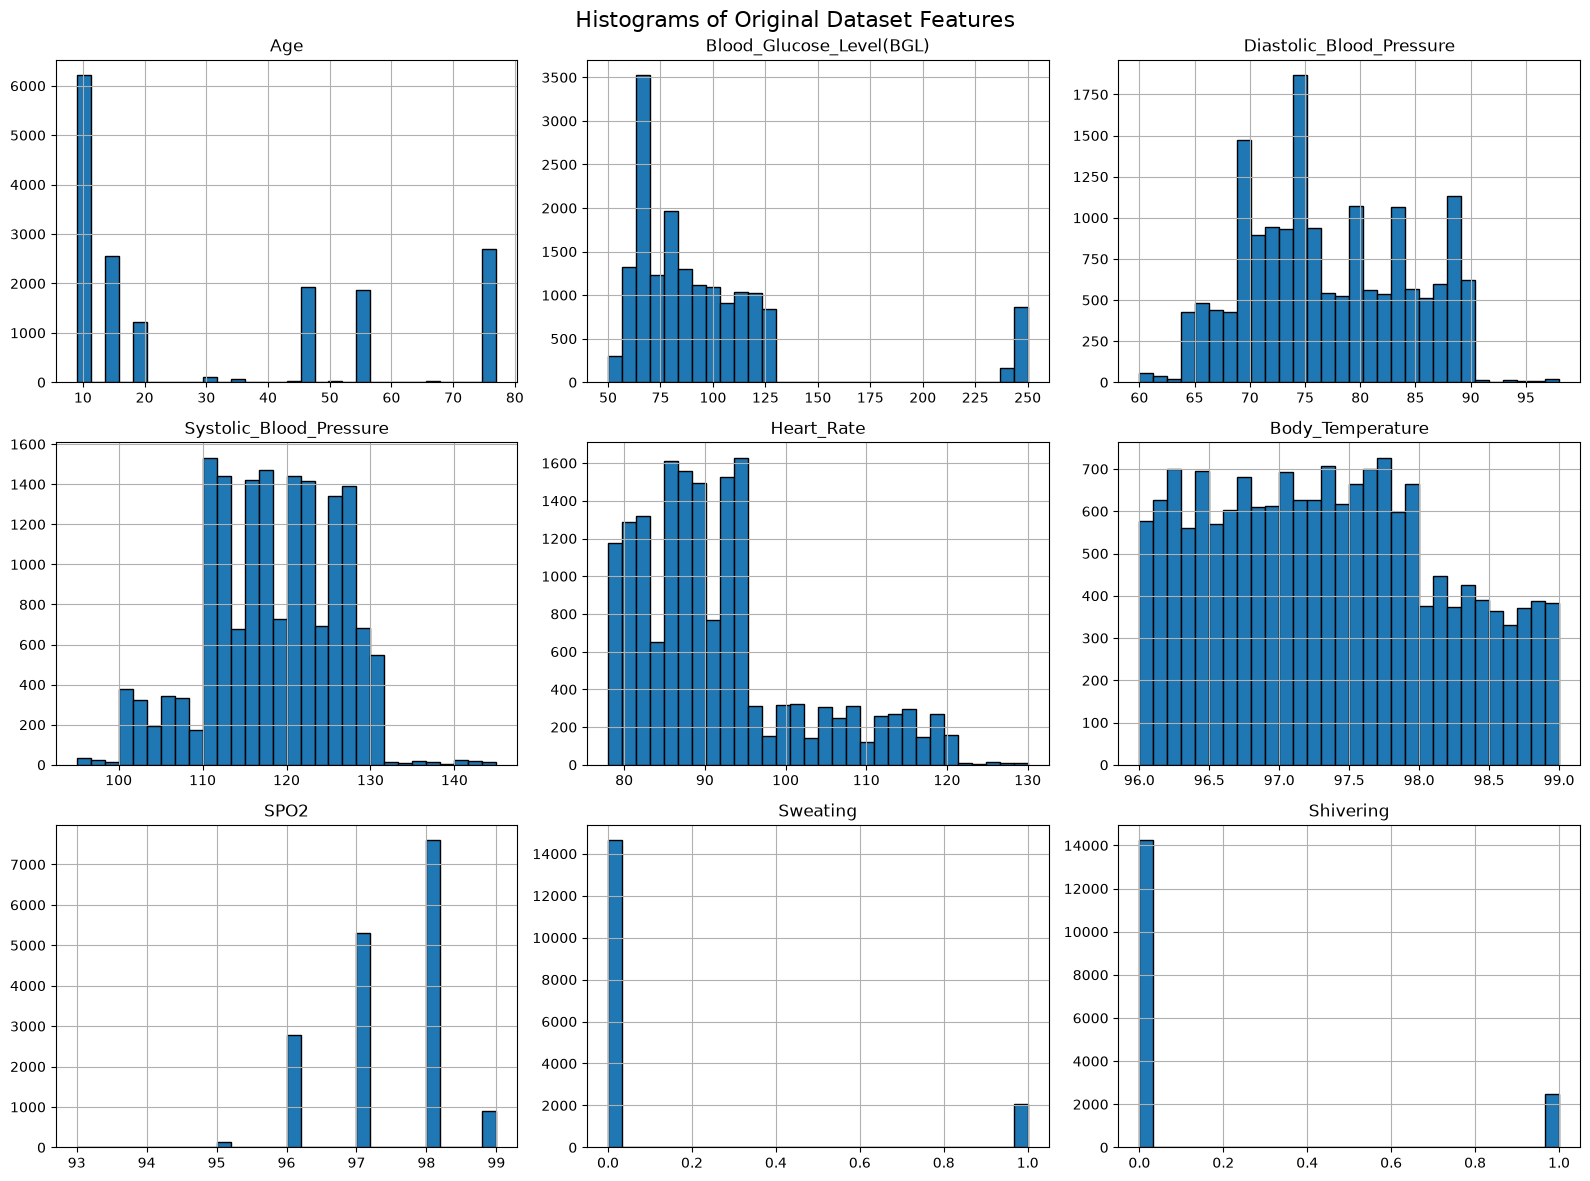

In [21]:
df.hist(figsize=(16, 12), bins=30, edgecolor='black', grid=True)
plt.suptitle('Histograms of Original Dataset Features', fontsize=16)
plt.tight_layout()
plt.show()

                               Age  Blood_Glucose_Level(BGL)  \
Age                       1.000000                  0.004152   
Blood_Glucose_Level(BGL)  0.004152                  1.000000   
Diastolic_Blood_Pressure  0.057780                  0.306326   
Systolic_Blood_Pressure   0.042821                  0.180240   
Heart_Rate               -0.056683                 -0.347942   
Body_Temperature          0.036642                  0.141250   
SPO2                      0.215818                  0.152088   
Sweating                 -0.232137                 -0.237511   
Shivering                -0.217199                 -0.288275   

                          Diastolic_Blood_Pressure  Systolic_Blood_Pressure  \
Age                                       0.057780                 0.042821   
Blood_Glucose_Level(BGL)                  0.306326                 0.180240   
Diastolic_Blood_Pressure                  1.000000                 0.237367   
Systolic_Blood_Pressure                   0

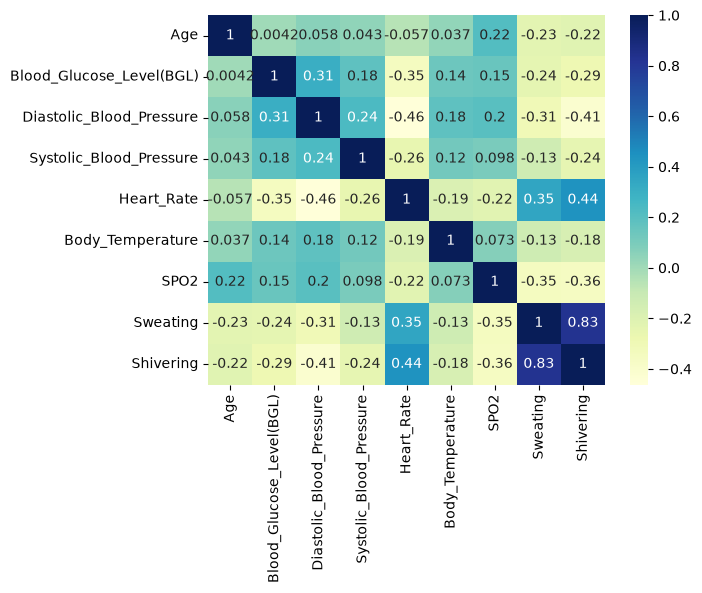

In [22]:
import seaborn as sns
# Compute correlation matrix
co_mtx = df.corr(numeric_only=True)

# Print correlation matrix
print(co_mtx)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()

MODEL TRAINING

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor

# Assuming df1500 contains your dataset

# Define features and target variable
features = ['Diastolic_Blood_Pressure_rolling_mean',
            'Diastolic_Blood_Pressure_rolling_std',
            'Systolic_Blood_Pressure_rolling_mean',
            'Systolic_Blood_Pressure_rolling_std', 
            'Heart_Rate_rolling_mean',
            'Heart_Rate_rolling_std', 
            'Body_Temperature_rolling_mean',
            'Body_Temperature_rolling_std', 
            'SPO2_rolling_mean',
            'SPO2_rolling_std']
target = 'Blood_Glucose_Level(BGL)'

X = df1500[features]
y = df1500[target]

# Step 2: Split into training (80%), validation (10%), and test (10%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% train, 20% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 10% val, 10% test

# Step 3: Normalize the data (CatBoost handles categorical features directly)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Step 4: Initialize and train the CatBoostRegressor
model = CatBoostRegressor(iterations=1000, 
                          learning_rate=0.1, 
                          depth=6, 
                          loss_function='RMSE',
                          cat_features=[],  # List categorical feature indices (if any)
                          verbose=200)

# Fit the model
model.fit(X_train, y_train)



# Step 5: Predictions and evaluation on the validation set
y_val_pred = model.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

print("Catboost Validation RMSE:", val_rmse)
print("Catboost Validation R² Score:", val_r2)

# Step 6: Predictions and evaluation on the test set
y_test_pred = model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Catboost Test RMSE:", test_rmse)
print("Catboost Test R² Score:", test_r2)

# Step 7: Feature importance
feature_importance = model.get_feature_importance()
print("Feature Importance:", feature_importance)


0:	learn: 40.9596258	total: 122ms	remaining: 2m 2s
200:	learn: 1.9572057	total: 596ms	remaining: 2.37s
400:	learn: 1.4333103	total: 1.07s	remaining: 1.6s
600:	learn: 1.2566875	total: 1.57s	remaining: 1.04s
800:	learn: 1.1119263	total: 2.04s	remaining: 508ms
999:	learn: 1.0080887	total: 2.56s	remaining: 0us
Catboost Validation RMSE: 3.0903876125603373
Catboost Validation R² Score: 0.9937947899947692
Catboost Test RMSE: 2.180245248440962
Catboost Test R² Score: 0.9977267623244427
Feature Importance: [25.91386439 44.39585345  3.51305968  9.87775678  1.95576815  1.37799074
  0.51819408 10.60075358  0.43931585  1.40744329]


In [24]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Define features and target variable
features = ['Diastolic_Blood_Pressure_rolling_mean',
            'Diastolic_Blood_Pressure_rolling_std',
            'Systolic_Blood_Pressure_rolling_mean',
            'Systolic_Blood_Pressure_rolling_std', 
            'Heart_Rate_rolling_mean',
            'Heart_Rate_rolling_std', 
            'Body_Temperature_rolling_mean',
            'Body_Temperature_rolling_std', 
            'SPO2_rolling_mean',
            'SPO2_rolling_std']
target = 'Blood_Glucose_Level(BGL)'

X = df1500[features]
y = df1500[target]

# Split into training (80%), validation (10%), and test (10%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Create Dataset for LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

# Define parameters for LightGBM
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
}

# Define early stopping callback
early_stopping_callback = lgb.early_stopping(stopping_rounds=100, verbose=True)

# Train the model with early stopping
num_round = 1000  # Number of boosting iterations

bst = lgb.train(params,
                train_data,
                num_round,
                valid_sets=[train_data, val_data],
                valid_names=['train', 'valid'],
                callbacks=[early_stopping_callback])

# Predict on the test set
y_pred = bst.predict(X_test, num_iteration=bst.best_iteration)

# Calculate RMSE and R² score
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("LightGBM Test RMSE:", test_rmse)
print("LightGBM Test R² Score:", test_r2)

# Feature importance
print("Feature Importance:", bst.feature_importance())


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000974 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2519
[LightGBM] [Info] Number of data points in the train set: 12376, number of used features: 10
[LightGBM] [Info] Start training from score 97.779169
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[659]	train's rmse: 1.19806	valid's rmse: 1.86509
LightGBM Test RMSE: 4.524635417816664
LightGBM Test R² Score: 0.990209579857465
Feature Importance: [2221 2151 1501 2540 2043 2147 1516 2041 2162 1448]


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# Assuming df1500smote has already been created and contains the balanced data with SMOTE

# Define features and target variable
features = ['Diastolic_Blood_Pressure_rolling_mean',
            'Diastolic_Blood_Pressure_rolling_std',
            'Systolic_Blood_Pressure_rolling_mean',
            'Systolic_Blood_Pressure_rolling_std', 
            'Heart_Rate_rolling_mean',
            'Heart_Rate_rolling_std', 
            'Body_Temperature_rolling_mean',
            'Body_Temperature_rolling_std', 
            'SPO2_rolling_mean',
            'SPO2_rolling_std']
target = 'Blood_Glucose_Level(BGL)'

X = df1500smote[features]
y = df1500smote[target]

# Step 2: Split into training (80%), validation (10%), and test (10%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% train, 20% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 10% val, 10% test

# Step 3: Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Step 4: Define the XGBoost model
xg_reg = xgb.XGBRegressor(objective='reg:squarederror')

# Step 5: Set up hyperparameter grid for tuning
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'n_estimators': [100, 200, 300],
    'colsample_bytree': [0.3, 0.5, 0.7],
    'alpha': [0, 1, 10],
}

# Step 6: Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=xg_reg, param_grid=param_grid, scoring='neg_mean_squared_error', 
                           cv=3, verbose=1, n_jobs=-1)

# Step 7: Fit the model to the training data
grid_search.fit(X_train, y_train)

# Step 8: Get the best parameters and the best score
best_params = grid_search.best_params_
best_score = np.sqrt(-grid_search.best_score_)  # Convert to RMSE

print("Best Hyperparameters:", best_params)
print("Best Cross-Validation RMSE:", best_score)

# Step 9: Train the model with the best parameters on the full training set
best_model = xgb.XGBRegressor(**best_params)
best_model.fit(X_train, y_train)

# Step 10: Predict on the validation set
y_val_pred = best_model.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

print("XG Boost Validation RMSE:", val_rmse)
print("XG BoostValidation R² Score:", val_r2)

# Step 11: Predict on the test set
y_test_pred = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("XG Boost Test RMSE:", test_rmse)
print("XG Boost Test R² Score:", test_r2)


Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best Hyperparameters: {'alpha': 1, 'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 300}
Best Cross-Validation RMSE: 3.0270460150549967
XG Boost Validation RMSE: 2.488724074791494
XG BoostValidation R² Score: 0.9944056272506714
XG Boost Test RMSE: 3.1013088170616254
XG Boost Test R² Score: 0.9915796518325806


In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import RandomUnderSampler

# Define features and target variable
features = ['Diastolic_Blood_Pressure_rolling_mean',
            'Diastolic_Blood_Pressure_rolling_std',
            'Systolic_Blood_Pressure_rolling_mean',
            'Systolic_Blood_Pressure_rolling_std', 
            'Heart_Rate_rolling_mean',
            'Heart_Rate_rolling_std', 
            'Body_Temperature_rolling_mean',
            'Body_Temperature_rolling_std', 
            'SPO2_rolling_mean',
            'SPO2_rolling_std']
target = 'Blood_Glucose_Level(BGL)'

X = df1500[features]
y = df1500[target]

# Step 2: Split into training (80%), validation (10%), and test (10%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% train, 20% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 10% val, 10% test

# Step 3: Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Step 4: Experiment with undersampling
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# Optionally, you can use ADASYN for oversampling
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

# Define and train the XGBoost model with undersampled data
xg_reg_under = xgb.XGBRegressor(objective='reg:squarederror')
xg_reg_under.fit(X_train_under, y_train_under)

# Step 5: Predict on the validation set using undersampled data
y_val_pred_under = xg_reg_under.predict(X_val)
val_rmse_under = np.sqrt(mean_squared_error(y_val, y_val_pred_under))
val_r2_under = r2_score(y_val, y_val_pred_under)

print("Validation RMSE (Undersampling):", val_rmse_under)
print("Validation R² Score (Undersampling):", val_r2_under)

# Define and train the XGBoost model with ADASYN oversampled data
xg_reg_adasyn = xgb.XGBRegressor(objective='reg:squarederror')
xg_reg_adasyn.fit(X_train_adasyn, y_train_adasyn)

# Step 6: Predict on the validation set using ADASYN data
y_val_pred_adasyn = xg_reg_adasyn.predict(X_val)
val_rmse_adasyn = np.sqrt(mean_squared_error(y_val, y_val_pred_adasyn))
val_r2_adasyn = r2_score(y_val, y_val_pred_adasyn)

print("Validation RMSE (ADASYN):", val_rmse_adasyn)
print("Validation R² Score (ADASYN):", val_r2_adasyn)

# Optionally, evaluate on the test set
y_test_pred_under = xg_reg_under.predict(X_test)
test_rmse_under = np.sqrt(mean_squared_error(y_test, y_test_pred_under))
test_r2_under = r2_score(y_test, y_test_pred_under)

print("Test RMSE (Undersampling):", test_rmse_under)
print("Test R² Score (Undersampling):", test_r2_under)

y_test_pred_adasyn = xg_reg_adasyn.predict(X_test)
test_rmse_adasyn = np.sqrt(mean_squared_error(y_test, y_test_pred_adasyn))
test_r2_adasyn = r2_score(y_test, y_test_pred_adasyn)

print("Test RMSE (ADASYN):", test_rmse_adasyn)
print("Test R² Score (ADASYN):", test_r2_adasyn)


Validation RMSE (Undersampling): 9.762837102054402
Validation R² Score (Undersampling): 0.9380726218223572
Validation RMSE (ADASYN): 2.6898365952448957
Validation R² Score (ADASYN): 0.9952991008758545
Test RMSE (Undersampling): 5.711995456041938
Test R² Score (Undersampling): 0.9843969345092773
Test RMSE (ADASYN): 3.839588051991591
Test R² Score (ADASYN): 0.9929497838020325


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import warnings

# Suppress warnings if needed
warnings.simplefilter(action='ignore', category=FutureWarning)

# --- Assuming df1500 is already created and loaded ---
# Example placeholder if you need to load it:
# try:
#     df1500 = pd.read_csv('your_data_1500.csv') # Or appropriate file loading
#     print("Data loaded successfully.")
# except FileNotFoundError:
#     print("Error: Data file not found.")
#     exit()
# except Exception as e:
#      print(f"Error loading data: {e}")
#      exit()

# Define features and target variable
features = ['Diastolic_Blood_Pressure_rolling_mean',
            'Diastolic_Blood_Pressure_rolling_std',
            'Systolic_Blood_Pressure_rolling_mean',
            'Systolic_Blood_Pressure_rolling_std',
            'Heart_Rate_rolling_mean',
            'Heart_Rate_rolling_std',
            'Body_Temperature_rolling_mean',
            'Body_Temperature_rolling_std',
            'SPO2_rolling_mean',
            'SPO2_rolling_std']
target = 'Blood_Glucose_Level(BGL)'

# Verify columns exist in the dataframe
# if not all(f in df1500.columns for f in features + [target]):
#     print(f"Error: DataFrame is missing required columns. Needed: {features + [target]}")
#     exit()

X = df1500smote[features]
y = df1500smote[target]

# Step 1: Split into training (80%), validation (10%), and test (10%) sets
# Keep random_state for reproducibility
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% train, 20% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 10% val, 10% test

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


# Step 2: Normalize the data (Fit on train, transform train, val, test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Data Normalized.")

# --- Plain Random Forest Training and Evaluation ---
print("\n--- Training Plain Random Forest ---")

# Step 3: Define the Random Forest model
# Using reasonable defaults: 100 trees, ensuring reproducibility
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Step 4: Train the model on the scaled training data
rf_reg.fit(X_train_scaled, y_train)
print("Training complete.")

# Step 5: Predict on the validation set
y_val_pred = rf_reg.predict(X_val_scaled)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

print(f"\nValidation RMSE: {val_rmse:.4f}")
print(f"Validation R² Score: {val_r2:.4f}")

# Step 6: Predict on the test set
y_test_pred = rf_reg.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nTest RMSE: {test_rmse:.4f}")
print(f"Test R² Score: {test_r2:.4f}")

Training set size: 24227
Validation set size: 3028
Test set size: 3029
Data Normalized.

--- Training Plain Random Forest ---
Training complete.

Validation RMSE: 3.5449
Validation R² Score: 0.9886

Test RMSE: 3.5864
Test R² Score: 0.9887


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor

# Assuming df1500 contains your dataset

# Define features and target variable
features = ['Diastolic_Blood_Pressure_rolling_mean',
            'Diastolic_Blood_Pressure_rolling_std',
            'Systolic_Blood_Pressure_rolling_mean',
            'Systolic_Blood_Pressure_rolling_std', 
            'Heart_Rate_rolling_mean',
            'Heart_Rate_rolling_std', 
            'Body_Temperature_rolling_mean',
            'Body_Temperature_rolling_std', 
            'SPO2_rolling_mean',
            'SPO2_rolling_std']
target = 'Blood_Glucose_Level(BGL)'

X = df1500smote[features]
y = df1500smote[target]

# Step 2: Split into training (80%), validation (10%), and test (10%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% train, 20% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 10% val, 10% test

# Step 3: Normalize the data (CatBoost handles categorical features directly)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Step 4: Initialize and train the CatBoostRegressor
model = CatBoostRegressor(iterations=1000, 
                          learning_rate=0.1, 
                          depth=6, 
                          loss_function='RMSE',
                          cat_features=[],  # List categorical feature indices (if any)
                          verbose=200)

# Fit the model
model.fit(X_train, y_train)

# Step 5: Predictions and evaluation on the validation set
y_val_pred = model.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

print("Validation RMSE:", val_rmse)
print("Validation R² Score:", val_r2)

# Step 6: Predictions and evaluation on the test set
y_test_pred = model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Test RMSE:", test_rmse)
print("Test R² Score:", test_r2)

# Step 7: Feature importance
feature_importance = model.get_feature_importance()
print("Feature Importance:", feature_importance)


0:	learn: 30.5215513	total: 13.4ms	remaining: 13.4s
200:	learn: 3.1845361	total: 623ms	remaining: 2.48s
400:	learn: 2.6830326	total: 1.19s	remaining: 1.78s
600:	learn: 2.4207960	total: 1.72s	remaining: 1.15s
800:	learn: 2.2464532	total: 2.33s	remaining: 579ms
999:	learn: 2.1023260	total: 2.9s	remaining: 0us
Validation RMSE: 2.672436109841085
Validation R² Score: 0.9935491885006873
Test RMSE: 2.819383436824062
Test R² Score: 0.9930409759818368
Feature Importance: [28.26875738 37.81413012  3.16138074  9.35632941  1.89742423  1.68210786
  0.81102384 11.91600761  2.64404318  2.44879564]


In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor
from imblearn.over_sampling import ADASYN

# Assuming df1500 contains your dataset

# Define features and target variable
features = ['Diastolic_Blood_Pressure_rolling_mean',
            'Diastolic_Blood_Pressure_rolling_std',
            'Systolic_Blood_Pressure_rolling_mean',
            'Systolic_Blood_Pressure_rolling_std', 
            'Heart_Rate_rolling_mean',
            'Heart_Rate_rolling_std', 
            'Body_Temperature_rolling_mean',
            'Body_Temperature_rolling_std', 
            'SPO2_rolling_mean',
            'SPO2_rolling_std']
target = 'Blood_Glucose_Level(BGL)'

X = df1500[features]
y = df1500[target]

# Step 2: Split into training (80%), validation (10%), and test (10%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% train, 20% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 10% val, 10% test

# Step 3: Normalize the data (CatBoost handles categorical features directly)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Step 4: Apply ADASYN oversampling
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

# Step 5: Initialize and train the CatBoostRegressor with ADASYN data
model_adasyn = CatBoostRegressor(iterations=1000, 
                              learning_rate=0.1, 
                              depth=6, 
                              loss_function='RMSE',
                              cat_features=[],  # List categorical feature indices (if any)
                              verbose=200)

# Fit the model with ADASYN oversampled data
model_adasyn.fit(X_train_adasyn, y_train_adasyn)

# Step 6: Predictions and evaluation on the validation set (ADASYN)
y_val_pred_adasyn = model_adasyn.predict(X_val)
val_rmse_adasyn = np.sqrt(mean_squared_error(y_val, y_val_pred_adasyn))
val_r2_adasyn = r2_score(y_val, y_val_pred_adasyn)

print("Validation RMSE (ADASYN):", val_rmse_adasyn)
print("Validation R² Score (ADASYN):", val_r2_adasyn)

# Step 7: Predictions and evaluation on the test set (ADASYN)
y_test_pred_adasyn = model_adasyn.predict(X_test)
test_rmse_adasyn = np.sqrt(mean_squared_error(y_test, y_test_pred_adasyn))
test_r2_adasyn = r2_score(y_test, y_test_pred_adasyn)

print("Test RMSE (ADASYN):", test_rmse_adasyn)
print("Test R² Score (ADASYN):", test_r2_adasyn)

# Step 8: Feature importance (ADASYN)
feature_importance_adasyn = model_adasyn.get_feature_importance()
print("Feature Importance (ADASYN):", feature_importance_adasyn)

0:	learn: 47.0345660	total: 9.83ms	remaining: 9.82s
200:	learn: 2.4461351	total: 1.75s	remaining: 6.96s
400:	learn: 2.1000671	total: 3.36s	remaining: 5.01s
600:	learn: 1.9256502	total: 5.01s	remaining: 3.32s
800:	learn: 1.7989272	total: 6.41s	remaining: 1.59s
999:	learn: 1.7062069	total: 7.98s	remaining: 0us
Validation RMSE (ADASYN): 2.0988233517812387
Validation R² Score (ADASYN): 0.99713791616647
Test RMSE (ADASYN): 2.7074362094303384
Test R² Score (ADASYN): 0.9964944948161688
Feature Importance (ADASYN): [10.4969072  62.34851865  5.01687934  2.90324913  9.24062928  0.73487615
  1.48724906  2.32467433  1.28370881  4.16330803]
